In [1]:
#Import the Needed Packages
import warnings
warnings.filterwarnings('ignore')
import face_recognition

from pinecone import Pinecone, ServerlessSpec
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from tqdm import tqdm
from DLAIUtils import Utils

import contextlib
import glob
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import time

# get api key
utils = Utils()
PINECONE_API_KEY = utils.get_pinecone_api_key()

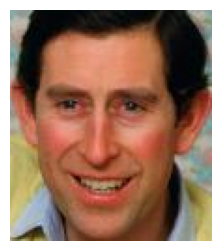

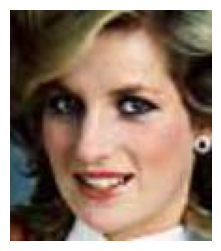

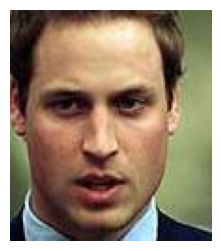

In [2]:
#Load dataset
def show_img(f):
    img = plt.imread(f)
    plt.figure(figsize=(4,3))
    plt.imshow(img)
    plt.axis('off')

show_img('family/dad/P06260_face5.jpg')
show_img('family/mom/P04407_face2.jpg')
show_img('family/child/P04414_face1.jpg')

In [3]:
#Setup pinecone
INDEX_NAME = utils.create_dlai_index_name('dl-ai')

pinecone = Pinecone(api_key=PINECONE_API_KEY)

In [4]:
#Create Embeddings Using DeepFace
def generate_vectors():
  VECTOR_FILE = "./vectors.vec"

  with contextlib.suppress(FileNotFoundError):
    os.remove(VECTOR_FILE)
  with open(VECTOR_FILE, "w") as f:
    for person in ["mom", "dad", "child"]:
      files = glob.glob(f'family/{person}/*')
      for file in tqdm(files):
        try:
          image = face_recognition.load_image_file(file)
          encodings = face_recognition.face_encodings(image)

          if len(encodings) == 0:
            continue

          embedding = encodings[0]  # 128-d vector
          f.write(f'{person}:{os.path.basename(file)}:{embedding.tolist()}\n')
        except (ValueError, UnboundLocalError, AttributeError) as e:
          print(e)

generate_vectors()

with open("vectors.vec") as f:
    for _ in range(10):
        print(f.readline().strip())

100%|███████████████████████████████████████████████████████████████████████████████████| 93/93 [00:01<00:00, 74.19it/s]

mom:P11987_face1.jpg:[-0.1321725994348526, 0.01303108036518097, 0.02419763058423996, -0.043119583278894424, -0.2048831284046173, -0.020301654934883118, 0.047474391758441925, -0.14372840523719788, 0.18466633558273315, -0.04260633513331413, 0.04414116591215134, -0.08378329128026962, -0.24824845790863037, 0.04723665863275528, -0.02276819944381714, 0.11833478510379791, -0.104804627597332, -0.22214652597904205, -0.1373545229434967, -0.09565624594688416, -0.02167973853647709, 0.06502451747655869, 0.02028162032365799, 0.0784185454249382, -0.20879366993904114, -0.22774088382720947, -0.09049494564533234, -0.09015894681215286, 0.027354765683412552, -0.0022242367267608643, 0.028672240674495697, 0.14836335182189941, -0.14105261862277985, -0.013882279396057129, 0.10480845719575882, 0.08777590095996857, -0.026871077716350555, -0.12621957063674927, 0.17398084700107574, -0.05574691295623779, -0.21014375984668732, 0.021556302905082703, 0.10725570470094681, 0.1740664839744568, 0.22814391553401947, 0.014

200it [00:00, 10747.60it/s]


transform 64 vectors


200it [00:00, 11916.82it/s]


transform 83 vectors


200it [00:00, 18379.14it/s]


transform 53 vectors


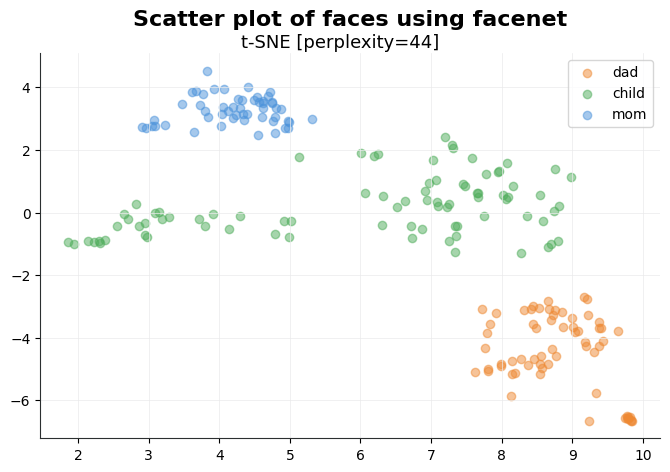

In [5]:
#Plot the Data of Images
def gen_tsne_df(person, perplexity):
    vectors =[]
    with open('./vectors.vec', 'r') as f:
      for line in tqdm(f):
        p, orig_img, v = line.split(':')
        if person == p:
            vectors.append(eval(v))
    pca = PCA(n_components=8)
    tsne = TSNE(2, perplexity=perplexity, random_state = 0, max_iter=1000,
        verbose=0, metric='euclidean', learning_rate=75)
    print(f'transform {len(vectors)} vectors')
    pca_transform = pca.fit_transform(vectors)
    embeddings2d = tsne.fit_transform(pca_transform)
    return pd.DataFrame({'x':embeddings2d[:,0], 'y':embeddings2d[:,1]})

def plot_tsne(perplexity, model):
    (_, ax) = plt.subplots(figsize=(8,5))
    #plt.style.use('seaborn-whitegrid')
    plt.grid(color='#EAEAEB', linewidth=0.5)
    ax.spines['top'].set_color(None)
    ax.spines['right'].set_color(None)
    ax.spines['left'].set_color('#2B2F30')
    ax.spines['bottom'].set_color('#2B2F30')
    colormap = {'dad':'#ee8933', 'child':'#4fad5b', 'mom':'#4c93db'}

    for person in colormap:
        embeddingsdf = gen_tsne_df(person, perplexity)
        ax.scatter(embeddingsdf.x, embeddingsdf.y, alpha=.5, 
                   label=person, color=colormap[person])
    plt.title(f'Scatter plot of faces using {model}', fontsize=16, fontweight='bold', pad=20)
    plt.suptitle(f't-SNE [perplexity={perplexity}]', y=0.92, fontsize=13)
    plt.legend(loc='best', frameon=True)
    plt.show()

plot_tsne(44, 'facenet')

In [6]:
#Store the Embeddings in Pinecone

if INDEX_NAME in [index.name for index in pinecone.list_indexes()]:
  pinecone.delete_index(INDEX_NAME)
pinecone.create_index(name=INDEX_NAME, dimension=128, metric='cosine',
  spec=ServerlessSpec(cloud='aws', region='us-east-1'))

index = pinecone.Index(INDEX_NAME)

def store_vectors():
  with open("vectors.vec", "r") as f:
    for line in tqdm(f):
        person, file, vec = line.split(':')
        index.upsert([(f'{person}-{file}', eval(vec), {"person":person, "file":file})])
store_vectors()

index.describe_index_stats()

200it [01:48,  1.85it/s]


{'_response_info': {'raw_headers': {'connection': 'keep-alive',
                                    'content-length': '185',
                                    'content-type': 'application/json',
                                    'date': 'Fri, 27 Mar 2026 11:07:49 GMT',
                                    'grpc-status': '0',
                                    'server': 'envoy',
                                    'x-envoy-upstream-service-time': '40',
                                    'x-pinecone-request-latency-ms': '40',
                                    'x-pinecone-response-duration-ms': '42'}},
 'dimension': 128,
 'index_fullness': 0.0,
 'memoryFullness': 0.0,
 'metric': 'cosine',
 'namespaces': {'__default__': {'vector_count': 200}},
 'storageFullness': 0.0,
 'total_vector_count': 200,
 'vector_type': 'dense'}

In [7]:
#Calculate the Similarity Scores

def test(vec_groups, parent, child):
  index = pinecone.Index(INDEX_NAME)
  parent_vecs = vec_groups[parent]
  K = 10
  SAMPLE_SIZE = 10
  sum = 0
  for i in tqdm(range(0,SAMPLE_SIZE)):
    query_response = index.query(
      top_k=K,
      vector = parent_vecs[i],
      filter={
        "person": {"$eq": child}
      }
    )
    for row in query_response["matches"]:
      sum  = sum + row["score"]
  print(f'\n\n{parent} AVG: {sum / (SAMPLE_SIZE*K)}')

def compute_scores():
  index = pinecone.Index(INDEX_NAME)
  vec_groups = {"dad":[], "mom":[], "child":[]}
  with open("vectors.vec", "r") as f:
    for line in tqdm(f):
      person, file, vec = line.split(':')
      vec_groups[person].append(eval(vec))
  print(f"DAD {'-' * 20}")
  test(vec_groups, "dad", "child")
  print(f"MOM {'-' * 20}")
  test(vec_groups, "mom", "child")

compute_scores()

200it [00:00, 4965.11it/s]


DAD --------------------


100%|███████████████████████████████████████████████████████████████████████████████████| 10/10 [00:03<00:00,  2.74it/s]




dad AVG: 0.9012295581500004
MOM --------------------


100%|███████████████████████████████████████████████████████████████████████████████████| 10/10 [00:03<00:00,  3.11it/s]



mom AVG: 0.8892747600900001


[-0.13173775  0.10813349  0.02140463  0.03197057 -0.16936557  0.06635706
 -0.04840806 -0.15870355  0.10783498 -0.06577392  0.24366719 -0.04940177
 -0.25875634 -0.01886394  0.00683593  0.13190424 -0.09840275 -0.07709615
 -0.13238913 -0.08298738 -0.01057296  0.01636682  0.07032299 -0.05159575
 -0.16030778 -0.32776955 -0.08888538 -0.06768097  0.13723196 -0.03083429
 -0.00245059  0.0663633  -0.14891103 -0.06405547  0.04945138  0.09991304
 -0.03353186 -0.05306824  0.21025895 -0.09959419 -0.15004162  0.0312136
  0.0383411   0.24065182  0.1526912   0.07231037  0.09136897 -0.07444569
  0.10946179 -0.30530846  0.11980544  0.03368996  0.13162571  0.02373379
  0.0823966  -0.23918618 -0.01522616  0.21530694 -0.1598492   0.16341713
  0.14025301 -0.06931312 -0.04059469 -0.12344591  0.23420617  0.14424318
 -0.10915768 -0.14826696  0.22832385 -0.1252826   0.01099742  0.07904599
 -0.09797166 -0.20765866 -0.33564246  0.07867742  0.43241963  0.18784642
 -0.18114272 -0.08843367  0.02474762  0.07747486  0.

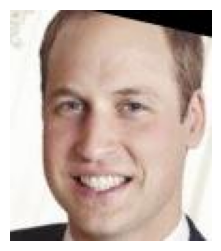

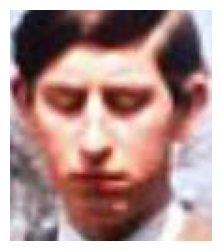

In [8]:
#Check the Matching Images
child_base = 'family/child/P06310_face1.jpg'
show_img(child_base)

# Generate embedding using face_recognition
image = face_recognition.load_image_file(child_base)
embedding = face_recognition.face_encodings(image)[0]
print(embedding)

query_response = index.query(
      top_k=3,
      vector = embedding.tolist(),
      filter={
        "person": {"$eq": "dad"}
      },
      include_metadata=True
)

print(query_response)

photo = query_response['matches'][0]['metadata']['file']

show_img(f'family/dad/{photo}')